# Classifiction - Prostate Cancer 

In [121]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [122]:
prostate_cancer = pd.read_csv("/Users/maddiemann/Documents/MATH-4025-sp26/Math-4025-Project-Maddie-Mann/Data/prad_tcga_pan_can_atlas_2018_clinical_data.tsv", sep='\t')

In [123]:
prostate_cancer.columns = prostate_cancer.columns.str.replace(' ', '_')
prostate_cancer.columns = prostate_cancer.columns.str.replace(r'[\(\)]', '', regex=True)

In [124]:
non_predictor = ['Study_ID', 'Patient_ID', 'Sample_ID', 'Patient_Weight', 
                'Cancer_Type', 'Cancer_Type_Detailed', 'Sex', 'Number_of_Samples_Per_Patient', 
                'American_Joint_Committee_on_Cancer_Metastasis_Stage_Code', 
                'Primary_Lymph_Node_Presentation_Assessment', 'Neoplasm_Disease_Stage_American_Joint_Committee_on_Cancer_Code', 
                'American_Joint_Committee_on_Cancer_Publication_Version_Type', 
                'Neoplasm_Disease_Stage_American_Joint_Committee_on_Cancer_Code', 'TCGA_PanCanAtlas_Cancer_Type_Acronym',
                'Last_Alive_Less_Initial_Pathologic_Diagnosis_Date_Calculated_Day_Value', 'Disease-specific_Survival_status',
                'Ethnicity_Category', 'Neoplasm_Histologic_Grade', 'Neoadjuvant_Therapy_Type_Administered_Prior_To_Resection_Text', 'ICD-10_Classification', 'International_Classification_of_Diseases_for_Oncology,_Third_Edition_ICD-O-3_Histology_Code',
                'International_Classification_of_Diseases_for_Oncology,_Third_Edition_ICD-O-3_Site_Code', 
                'Informed_consent_verified', 'Oncotree_Code', 'Other_Patient_ID',
                'American_Joint_Committee_on_Cancer_Metastasis_Stage_Code', 'Primary_Lymph_Node_Presentation_Assessment', 
                'Race_Category', 'Number_of_Samples_Per_Patient', 'Sample_Type',
                'Somatic_Status', 'Subtype', 'Tissue_Source_Site', 'Tissue_Prospective_Collection_Indicator',
       'Tissue_Retrospective_Collection_Indicator', 'Tissue_Source_Site_Code', 'Tumor_Disease_Anatomic_Site','Last_Communication_Contact_from_Initial_Pathologic_Diagnosis_Date', 'Birth_from_Initial_Pathologic_Diagnosis_Date',
       'Form_completion_date']

In [125]:
prostate_cancer = prostate_cancer.drop(columns =non_predictor)

In [126]:
prostate_cancer.columns

Index(['Diagnosis_Age', 'Aneuploidy_Score', 'Buffa_Hypoxia_Score', 'Disease_Free_Months', 'Disease_Free_Status',
       'Months_of_disease-specific_survival', 'Fraction_Genome_Altered', 'Genetic_Ancestry_Label', 'In_PanCan_Pathway_Analysis',
       'MSI_MANTIS_Score', 'MSIsensor_Score', 'Mutation_Count', 'New_Neoplasm_Event_Post_Initial_Therapy_Indicator',
       'Overall_Survival_Months', 'Overall_Survival_Status',
       'Neoplasm_Disease_Lymph_Node_Stage_American_Joint_Committee_on_Cancer_Code',
       'American_Joint_Committee_on_Cancer_Tumor_Stage_Code', 'Person_Neoplasm_Cancer_Status', 'Progress_Free_Survival_Months',
       'Progression_Free_Status', 'Prior_Diagnosis', 'Radiation_Therapy', 'Ragnum_Hypoxia_Score', 'Tumor_Break_Load',
       'TMB_nonsynonymous', 'Tumor_Type', 'Winter_Hypoxia_Score'],
      dtype='str')

In [127]:
prostate_cancer= prostate_cancer.rename(columns={
    'Neoplasm_Disease_Lymph_Node_Stage_American_Joint_Committee_on_Cancer_Code': 'Lymph_Node_Stage',
    'American_Joint_Committee_on_Cancer_Tumor_Stage_Code': 'Tumor_Stage' 
})

In [128]:
# Dropping the other potential target variables
other_target = ['Disease_Free_Months', 'Disease_Free_Status','Progress_Free_Survival_Months', 'Months_of_disease-specific_survival', 'Overall_Survival_Months', 'Overall_Survival_Status', 'New_Neoplasm_Event_Post_Initial_Therapy_Indicator', 'Person_Neoplasm_Cancer_Status']
prostate_class = prostate_cancer.drop(columns =other_target)

In [129]:
prostate_class['Progression_Free_Status'] = prostate_class['Progression_Free_Status'].astype(str).str[0].astype(int)

In [130]:
prostate_class.columns

Index(['Diagnosis_Age', 'Aneuploidy_Score', 'Buffa_Hypoxia_Score', 'Fraction_Genome_Altered', 'Genetic_Ancestry_Label',
       'In_PanCan_Pathway_Analysis', 'MSI_MANTIS_Score', 'MSIsensor_Score', 'Mutation_Count', 'Lymph_Node_Stage', 'Tumor_Stage',
       'Progression_Free_Status', 'Prior_Diagnosis', 'Radiation_Therapy', 'Ragnum_Hypoxia_Score', 'Tumor_Break_Load',
       'TMB_nonsynonymous', 'Tumor_Type', 'Winter_Hypoxia_Score'],
      dtype='str')

In [131]:
X = prostate_class.drop(columns = 'Progression_Free_Status')
y = prostate_class['Progression_Free_Status']

In [132]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size= 0.7,
    random_state=4025,
    stratify=y
)

In [133]:
prostate_class.dtypes

Diagnosis_Age                   int64
Aneuploidy_Score              float64
Buffa_Hypoxia_Score           float64
Fraction_Genome_Altered       float64
Genetic_Ancestry_Label            str
In_PanCan_Pathway_Analysis        str
MSI_MANTIS_Score              float64
MSIsensor_Score               float64
Mutation_Count                float64
Lymph_Node_Stage                  str
Tumor_Stage                       str
Progression_Free_Status         int64
Prior_Diagnosis                   str
Radiation_Therapy                 str
Ragnum_Hypoxia_Score          float64
Tumor_Break_Load              float64
TMB_nonsynonymous             float64
Tumor_Type                        str
Winter_Hypoxia_Score          float64
dtype: object

In [134]:
cat_vars = ['Genetic_Ancestry_Label', 'In_PanCan_Pathway_Analysis', 'Lymph_Node_Stage', 'Tumor_Stage', 'Prior_Diagnosis', 'Radiation_Therapy', 'Tumor_Type']
num_vars = ['Diagnosis_Age', 'Aneuploidy_Score', 'Buffa_Hypoxia_Score', 'Fraction_Genome_Altered', 'MSI_MANTIS_Score', 'MSIsensor_Score', 'Mutation_Count', 'Ragnum_Hypoxia_Score', 'Tumor_Break_Load', 'TMB_nonsynonymous', 'Winter_Hypoxia_Score']

In [135]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
cat_pipe = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean'))
])
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_vars),
    ('num', num_pipe, num_vars),
])

tree_pipe = Pipeline([
    ('preproc', preprocessor),
    ('tree', DecisionTreeClassifier(random_state=4025, max_depth=10))
])


In [136]:
tree_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

In [137]:
from sklearn.metrics import accuracy_score, recall_score, classification_report

y_pred = tree_pipe.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       280
           1       0.98      0.95      0.97        65

    accuracy                           0.99       345
   macro avg       0.99      0.98      0.98       345
weighted avg       0.99      0.99      0.99       345



In [166]:
tree_tune_pipe = Pipeline([
    ('preproc', preprocessor),
    ('tree', DecisionTreeClassifier(random_state=4025, ccp_alpha=0.0001))
])

In [167]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits = 10, shuffle = True, random_state=4025)
ccp_alphas = np.logspace(-4, -1, 10)
param_grid = {
    'tree__max_depth': [3, 5, 10, None], 
    'tree__min_samples_split': [2, 5, 10],
    'tree__class_weight': ['balanced'] 
}
tree_grid = GridSearchCV(
    estimator=tree_tune_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy'
)

tree_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=4025))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'tree__class_weight': ['balanced'], 'tree__max_depth': [3, 5, ...], 'tree__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for e

In [168]:
y_pred = tree_pipe.predict(X_train)
print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       280
           1       0.98      0.95      0.97        65

    accuracy                           0.99       345
   macro avg       0.99      0.98      0.98       345
weighted avg       0.99      0.99      0.99       345



In [ ]:
best_pipeline = tree_grid.best_estimator_
actual_tree = best_pipeline[-1]


preprocessor = best_pipeline[0]


new_feature_names = preprocessor.get_feature_names_out()

importances = actual_tree.feature_importances_
feature_importance_df = pd.Series(importances, index=new_feature_names)
sorted_importance = feature_importance_df.sort_values(ascending=False)

print(sorted_importance.head(10))

num__Fraction_Genome_Altered    0.211726
num__Tumor_Break_Load           0.152102
num__MSI_MANTIS_Score           0.103555
num__Buffa_Hypoxia_Score        0.097678
num__Diagnosis_Age              0.094939
num__Winter_Hypoxia_Score       0.078059
cat__Tumor_Stage_T2C            0.048858
num__Ragnum_Hypoxia_Score       0.044324
num__TMB_nonsynonymous          0.043433
num__Mutation_Count             0.029046
dtype: float64


<Axes: xlabel='Progression_Free_Status', ylabel='Fraction_Genome_Altered'>

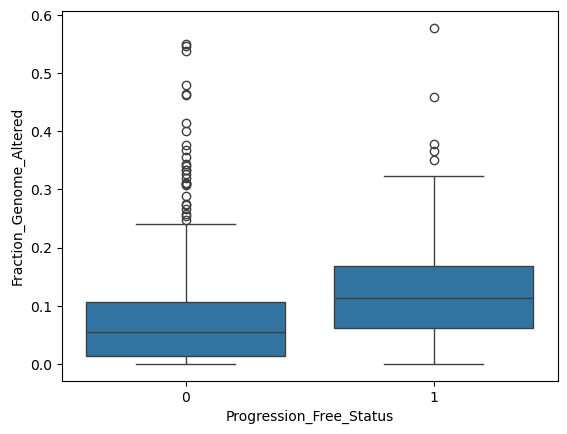

In [164]:
import seaborn as sns
sns.boxplot(x='Progression_Free_Status', y='Fraction_Genome_Altered', data=prostate_class)

In [170]:
tree_grid.best_params_

{'tree__class_weight': 'balanced',
 'tree__max_depth': None,
 'tree__min_samples_split': 2}

In [171]:
y_pred_test = tree_grid.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       121
           1       0.19      0.21      0.20        28

    accuracy                           0.68       149
   macro avg       0.50      0.50      0.50       149
weighted avg       0.69      0.68      0.69       149



The best ccp_alpha is 0.0001 and the metrics above are what it gives on the test set. 

## Random Forest Classifier 

In [173]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=6, 
    class_weight='balanced',
    random_state=42
)


rf_pipeline = Pipeline([
    ('preprocessor', preprocessor), 
    ('rf', rf_classifier)
])


rf_pipeline.fit(X_train, y_train)


importances = rf_pipeline.named_steps['rf'].feature_importances_
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

rf_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(rf_importance_df.head(10))

num__Fraction_Genome_Altered    0.133355
num__MSI_MANTIS_Score           0.106218
num__Tumor_Break_Load           0.092427
num__Diagnosis_Age              0.078290
num__Buffa_Hypoxia_Score        0.065345
num__Mutation_Count             0.061803
num__TMB_nonsynonymous          0.060771
num__Aneuploidy_Score           0.058889
num__Winter_Hypoxia_Score       0.056531
cat__Tumor_Stage_T2C            0.055166
dtype: float64


In [174]:
y_pred_rf = rf_pipeline.predict(X_train)
print(classification_report(y_train, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       280
           1       0.78      0.95      0.86        65

    accuracy                           0.94       345
   macro avg       0.88      0.94      0.91       345
weighted avg       0.95      0.94      0.94       345



In [176]:
y_pred_rf_test = rf_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_rf_test))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       121
           1       0.30      0.25      0.27        28

    accuracy                           0.75       149
   macro avg       0.57      0.56      0.56       149
weighted avg       0.73      0.75      0.74       149

